# 💳 Credit Card Fraud Detection — End-to-End ML Pipeline

A complete, production-style workflow for detecting fraudulent credit card transactions using multiple machine learning algorithms.

**What this notebook covers:**
1. Data loading & exploration (EDA)
2. Handling extreme class imbalance (SMOTE, class weights)
3. Feature scaling & preprocessing
4. Training 7 different classification algorithms
5. Model evaluation with imbalance-aware metrics (Precision, Recall, F1, ROC-AUC, PR-AUC)
6. Model comparison & selection
7. Feature importance analysis
8. Saving the final best model

**Dataset:** `creditcard.csv` — 15,000 transactions, 30 features (`Time`, `V1`–`V28` PCA-anonymized features, `Amount`) and a binary `Class` target (0 = legitimate, 1 = fraud), with a realistic ~1.3% fraud rate.

> ⚠️ Note: This repository ships a **synthetic but statistically realistic** dataset (same schema as the classic Kaggle "Credit Card Fraud Detection" dataset: PCA components V1–V28 + Time + Amount + Class) so the project can be run and shared without any licensing restrictions. Swap in the real Kaggle CSV (same column names) for production use — the pipeline works unchanged.


## 1. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score, f1_score,
    precision_score, recall_score, accuracy_score, matthews_corrcoef
)
import joblib

# Try to import XGBoost; fall back gracefully if unavailable
try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False
    print("xgboost not installed — run `pip install xgboost` to include it. Skipping for now.")

# Try to import imbalanced-learn for SMOTE
try:
    from imblearn.over_sampling import SMOTE
    IMBLEARN_AVAILABLE = True
except ImportError:
    IMBLEARN_AVAILABLE = False
    print("imbalanced-learn not installed — run `pip install imbalanced-learn` for SMOTE. Using class_weight fallback.")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 2. Load the Dataset

In [2]:
df = pd.read_csv("creditcard.csv")
print("Shape:", df.shape)
df.head()


Shape: (15000, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,133962.17,-0.487535,-1.359441,0.369666,-1.519566,0.668831,0.936229,-1.176006,0.509907,-0.341559,...,-0.325776,0.282762,-1.329415,-1.305212,-0.484805,-0.210397,0.948812,-0.671367,15.09,0
1,74590.77,-1.333995,1.109213,-0.307301,0.100410,-1.289527,0.613125,-0.330740,-1.242833,-0.952224,...,-1.459524,0.525908,0.769889,0.577967,-1.344659,0.370925,-1.268663,-0.029566,47.26,0
2,153560.29,0.204956,1.121466,-1.243459,-1.051903,0.689949,-0.959637,-0.679878,0.131212,-2.022217,...,0.401218,0.373287,0.816871,0.359270,0.208170,0.945955,0.325901,-0.641904,51.17,0
3,9859.06,1.230102,-2.213022,-0.480057,-1.858481,0.663098,-0.742764,3.019653,-0.517926,0.106363,...,1.277043,0.234797,-0.338206,1.276068,-0.791463,0.270708,-0.043748,-0.891417,34.90,0
4,69036.85,0.671256,0.769001,0.715875,-0.186758,0.447894,-0.784500,1.327286,0.214584,-1.001427,...,-0.446804,0.029583,1.852841,-0.072361,-0.300932,1.032032,-1.475596,0.343729,134.20,0


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    15000 non-null  float64
 1   V1      15000 non-null  float64
 2   V2      15000 non-null  float64
 3   V3      15000 non-null  float64
 4   V4      15000 non-null  float64
 5   V5      15000 non-null  float64
 6   V6      15000 non-null  float64
 7   V7      15000 non-null  float64
 8   V8      15000 non-null  float64
 9   V9      15000 non-null  float64
 10  V10     15000 non-null  float64
 11  V11     15000 non-null  float64
 12  V12     15000 non-null  float64
 13  V13     15000 non-null  float64
 14  V14     15000 non-null  float64
 15  V15     15000 non-null  float64
 16  V16     15000 non-null  float64
 17  V17     15000 non-null  float64
 18  V18     15000 non-null  float64
 19  V19     15000 non-null  float64
 20  V20     15000 non-null  float64
 21  V21     15000 non-null  float64
 22  V22     1

In [4]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Time,15000.0,85806.384191,49885.775587,2.010000,42614.895000,85272.015000,129316.727500,172766.330000
V1,15000.0,-0.010453,1.031179,-6.049655,-0.690314,0.002294,0.682651,3.976868
V2,15000.0,-0.001930,1.002749,-4.591547,-0.684638,0.004684,0.678329,4.865083
V3,15000.0,-0.001328,1.015587,-5.350026,-0.680595,0.018786,0.667482,3.707905
V4,15000.0,0.003230,1.028225,-4.449411,-0.688595,0.002946,0.694086,4.468232
V5,15000.0,0.008095,1.019714,-5.641308,-0.675689,0.005179,0.700591,5.981813
V6,15000.0,-0.022007,1.037175,-7.022581,-0.700877,-0.003856,0.672959,3.824992
V7,15000.0,-0.018896,1.014302,-4.930137,-0.683459,-0.016128,0.665137,3.678191
V8,15000.0,-0.037746,1.038618,-6.182388,-0.701016,-0.012655,0.650657,3.644306
V9,15000.0,-0.004100,1.000397,-4.391168,-0.678189,-0.011576,0.657482,4.178018


## 3. Exploratory Data Analysis (EDA)

In [5]:
# Check for missing values
print("Missing values per column:\n", df.isnull().sum().sum(), "total missing values")

# Class distribution
class_counts = df['Class'].value_counts()
fraud_pct = df['Class'].mean() * 100
print(f"\nLegitimate transactions: {class_counts[0]}")
print(f"Fraudulent transactions: {class_counts[1]}")
print(f"Fraud percentage: {fraud_pct:.3f}%")


Missing values per column:
 0 total missing values

Legitimate transactions: 14800
Fraudulent transactions: 200
Fraud percentage: 1.333%


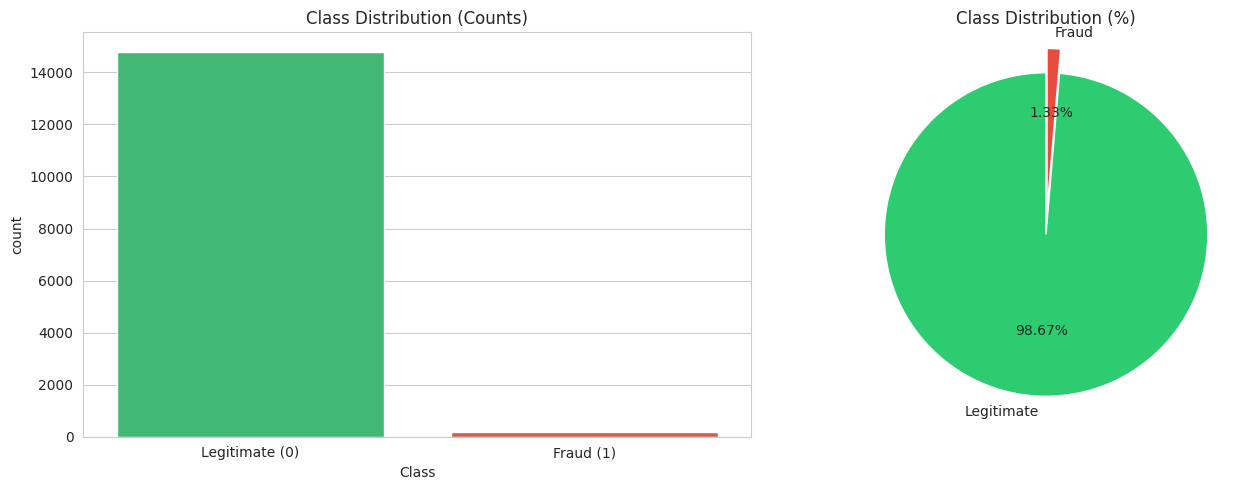

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x='Class', data=df, ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Class Distribution (Counts)')
axes[0].set_xticklabels(['Legitimate (0)', 'Fraud (1)'])

axes[1].pie(class_counts, labels=['Legitimate', 'Fraud'], autopct='%1.2f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90, explode=(0, 0.15))
axes[1].set_title('Class Distribution (%)')

plt.tight_layout()
plt.show()


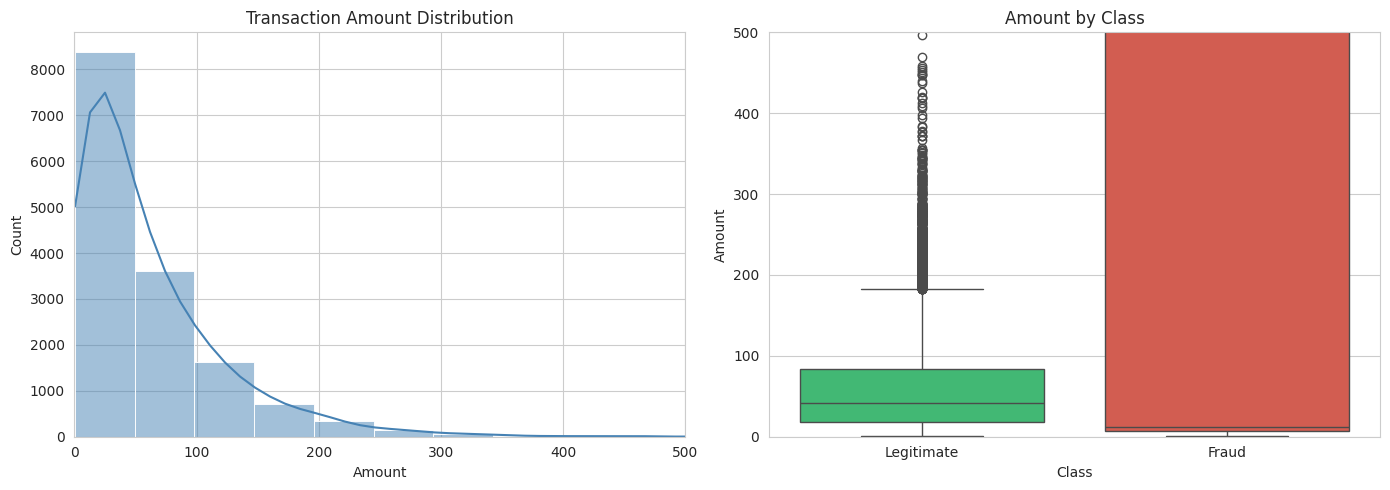

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['Amount'], bins=50, ax=axes[0], color='steelblue', kde=True)
axes[0].set_title('Transaction Amount Distribution')
axes[0].set_xlim(0, 500)

sns.boxplot(x='Class', y='Amount', data=df, ax=axes[1], palette=['#2ecc71', '#e74c3c'])
axes[1].set_title('Amount by Class')
axes[1].set_ylim(0, 500)
axes[1].set_xticklabels(['Legitimate', 'Fraud'])

plt.tight_layout()
plt.show()


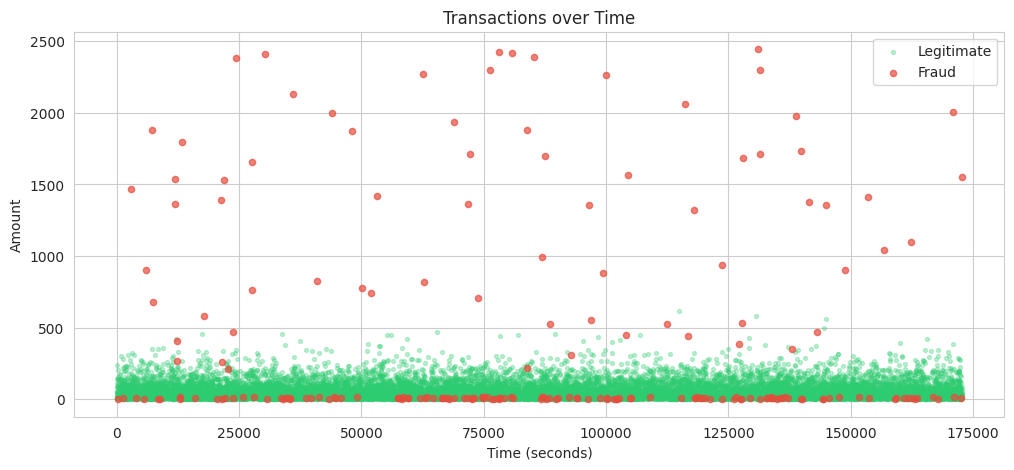

In [8]:
plt.figure(figsize=(12, 5))
plt.scatter(df[df['Class']==0]['Time'], df[df['Class']==0]['Amount'],
            alpha=0.3, s=8, label='Legitimate', color='#2ecc71')
plt.scatter(df[df['Class']==1]['Time'], df[df['Class']==1]['Amount'],
            alpha=0.7, s=20, label='Fraud', color='#e74c3c')
plt.xlabel('Time (seconds)')
plt.ylabel('Amount')
plt.title('Transactions over Time')
plt.legend()
plt.show()


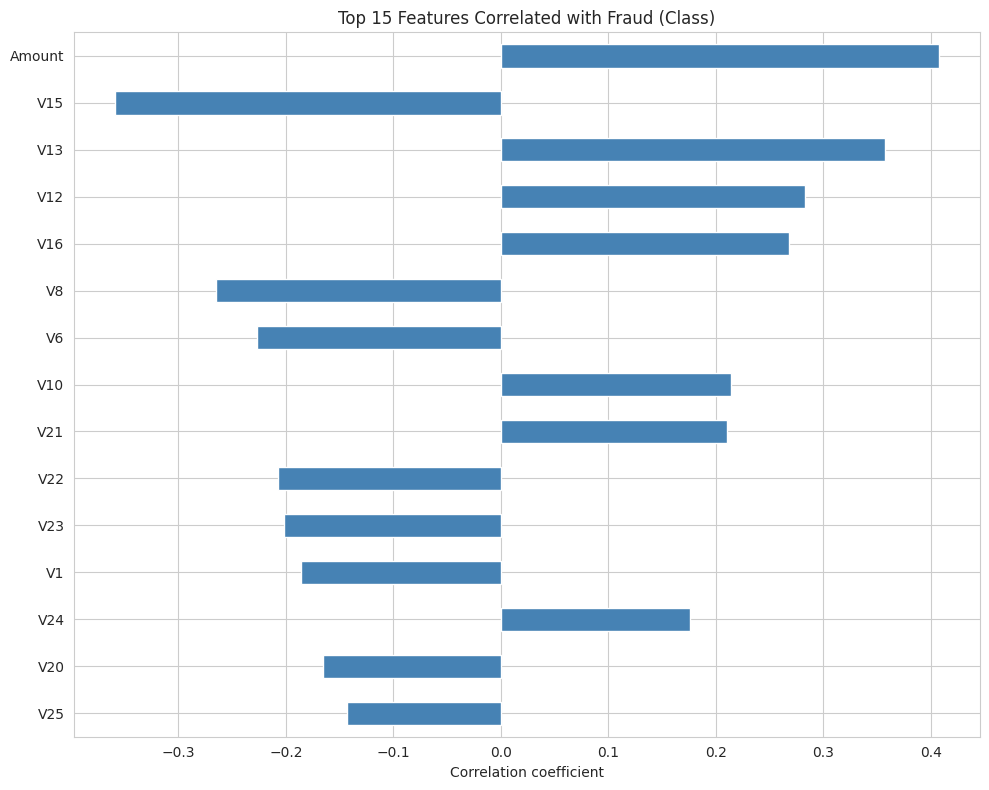

In [9]:
# Correlation of features with target (top absolute correlations)
corr_with_target = df.corr()['Class'].drop('Class').sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 8))
corr_with_target.head(15).plot(kind='barh', color='steelblue')
plt.title('Top 15 Features Correlated with Fraud (Class)')
plt.xlabel('Correlation coefficient')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


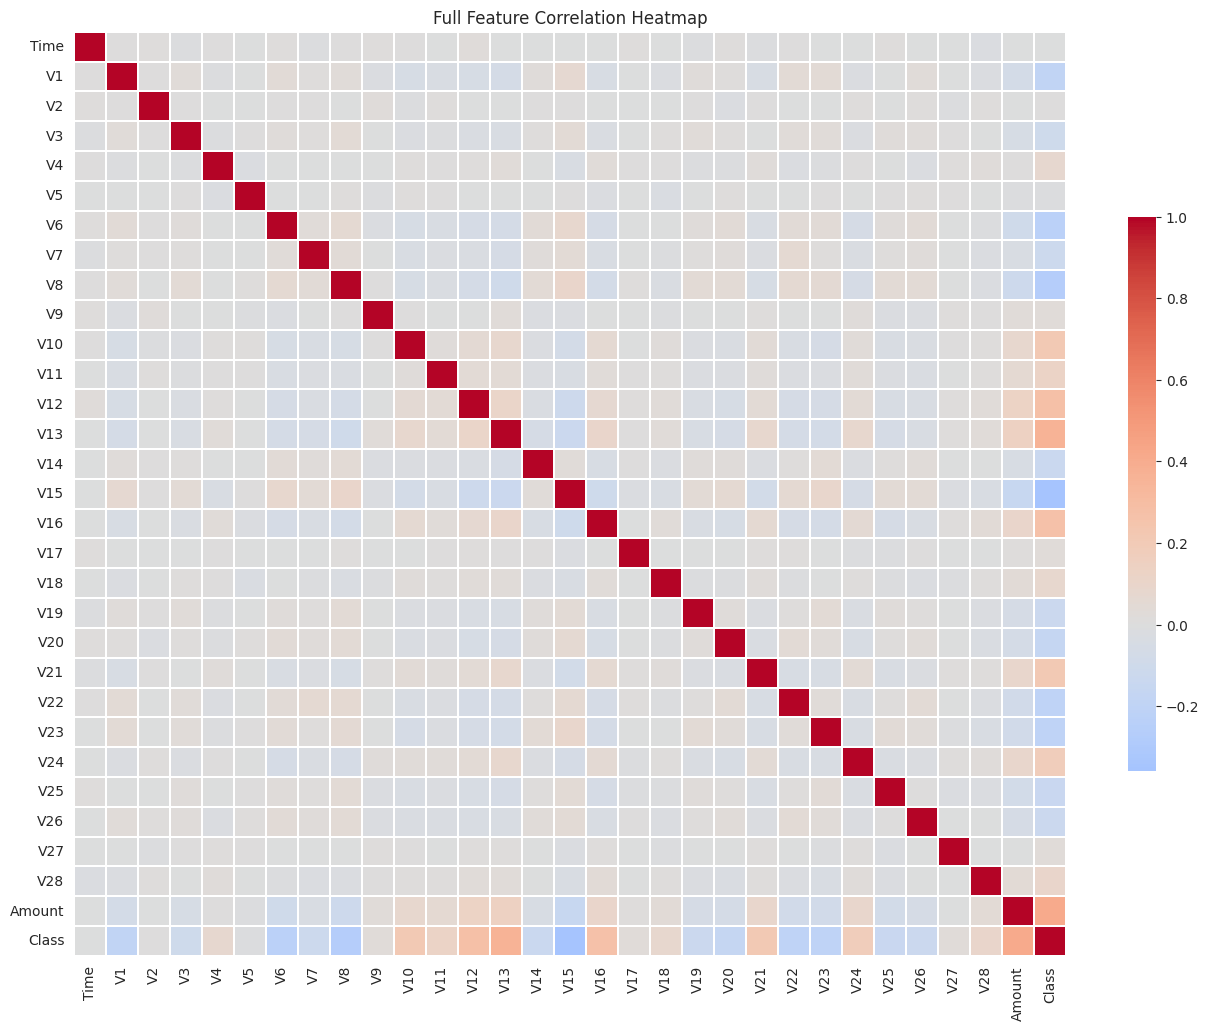

In [10]:
plt.figure(figsize=(16, 12))
sns.heatmap(df.corr(), cmap='coolwarm', center=0, linewidths=0.1, cbar_kws={'shrink': 0.6})
plt.title('Full Feature Correlation Heatmap')
plt.show()


## 4. Data Preprocessing

Steps:
- Scale `Time` and `Amount` (the only non-PCA-transformed features) using `RobustScaler`, which is less sensitive to outliers — important since fraud amounts are often extreme.
- Split into train/test using **stratified sampling** to preserve the class ratio.
- Address class imbalance with **SMOTE** (Synthetic Minority Over-sampling) on the training set only (never on test data, to avoid leakage).


In [11]:
df_processed = df.copy()

scaler = RobustScaler()
df_processed['Amount_scaled'] = scaler.fit_transform(df_processed[['Amount']])
df_processed['Time_scaled'] = scaler.fit_transform(df_processed[['Time']])
df_processed.drop(['Amount', 'Time'], axis=1, inplace=True)

# Reorder so Class is last
cols = [c for c in df_processed.columns if c != 'Class'] + ['Class']
df_processed = df_processed[cols]

X = df_processed.drop('Class', axis=1)
y = df_processed['Class']

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)


Feature matrix shape: (15000, 30)
Target shape: (15000,)


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape, " Fraud rate:", y_train.mean().round(4))
print("Test shape :", X_test.shape, " Fraud rate:", y_test.mean().round(4))


Train shape: (11250, 30)  Fraud rate: 0.0133
Test shape : (3750, 30)  Fraud rate: 0.0133


In [13]:
if IMBLEARN_AVAILABLE:
    smote = SMOTE(random_state=RANDOM_STATE)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
    print("Before SMOTE:", y_train.value_counts().to_dict())
    print("After SMOTE :", y_train_res.value_counts().to_dict())
else:
    # Fallback: keep original data; rely on class_weight='balanced' in models
    X_train_res, y_train_res = X_train, y_train
    print("SMOTE unavailable — using original imbalanced data with class_weight='balanced' in applicable models.")


Before SMOTE: {0: 11100, 1: 150}
After SMOTE : {0: 11100, 1: 11100}


## 5. Model Training

We train and compare **seven** classification algorithms:

| # | Algorithm | Notes |
|---|-----------|-------|
| 1 | Logistic Regression | Fast, interpretable baseline |
| 2 | K-Nearest Neighbors | Distance-based, sensitive to scaling |
| 3 | Gaussian Naive Bayes | Probabilistic baseline |
| 4 | Decision Tree | Simple, interpretable, prone to overfitting |
| 5 | Random Forest | Ensemble of trees, strong general performer |
| 6 | Gradient Boosting | Sequential boosting ensemble |
| 7 | XGBoost | Optimized gradient boosting (if installed) |

Each model is trained on the SMOTE-balanced training set and evaluated on the **untouched, imbalanced** test set — the only way to get a realistic sense of real-world performance.


In [14]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced'),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=12, random_state=RANDOM_STATE,
                                             class_weight='balanced', n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=150, max_depth=4, random_state=RANDOM_STATE),
}

if XGB_AVAILABLE:
    models["XGBoost"] = XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        eval_metric='logloss', random_state=RANDOM_STATE,
        scale_pos_weight=(y_train_res.value_counts()[0] / max(y_train_res.value_counts()[1], 1))
    )

print(f"Training {len(models)} models...")


Training 7 models...


In [15]:
results = []
fitted_models = {}
roc_data = {}
pr_data = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_res, y_train_res)
    fitted_models[name] = model

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)
    mcc = matthews_corrcoef(y_test, y_pred)

    results.append({
        "Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec,
        "F1-Score": f1, "ROC-AUC": roc_auc, "PR-AUC": pr_auc, "MCC": mcc
    })

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_data[name] = (fpr, tpr, roc_auc)

    prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_proba)
    pr_data[name] = (prec_curve, rec_curve, pr_auc)

results_df = pd.DataFrame(results).sort_values("F1-Score", ascending=False).reset_index(drop=True)
results_df


Training Logistic Regression...
Training K-Nearest Neighbors...


Training Naive Bayes...
Training Decision Tree...


Training Random Forest...


Training Gradient Boosting...


Training XGBoost...


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,MCC
0,Logistic Regression,0.999733,1.000000,0.98,0.989899,1.000000,1.000000,0.989816
1,K-Nearest Neighbors,0.999467,1.000000,0.96,0.979592,0.980000,0.960533,0.979531
2,Random Forest,0.999200,0.979592,0.96,0.969697,0.999978,0.998468,0.969342
3,Naive Bayes,0.998933,0.925926,1.00,0.961538,0.999995,0.999608,0.961730
4,Gradient Boosting,0.998133,0.921569,0.94,0.930693,0.999795,0.987048,0.929794
5,XGBoost,0.998133,0.921569,0.94,0.930693,0.999827,0.988610,0.929794
6,Decision Tree,0.992800,0.671642,0.90,0.769231,0.945703,0.549254,0.774126


## 6. Model Evaluation & Comparison

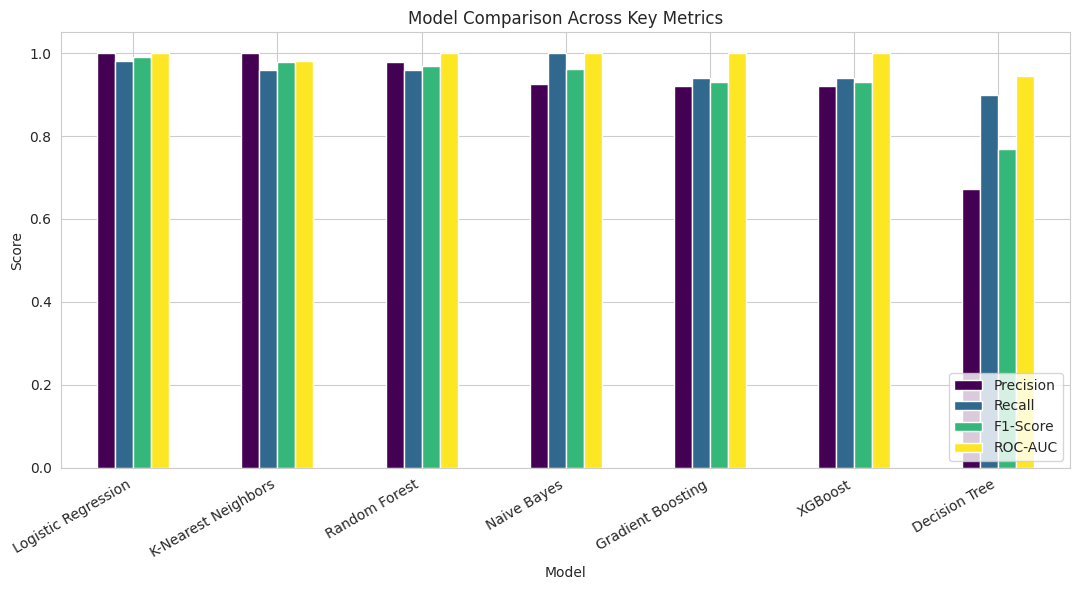

In [16]:
fig, ax = plt.subplots(figsize=(11, 6))
metrics_to_plot = ["Precision", "Recall", "F1-Score", "ROC-AUC"]
results_df.set_index("Model")[metrics_to_plot].plot(kind='bar', ax=ax, colormap='viridis')
plt.title("Model Comparison Across Key Metrics")
plt.ylabel("Score")
plt.xticks(rotation=30, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


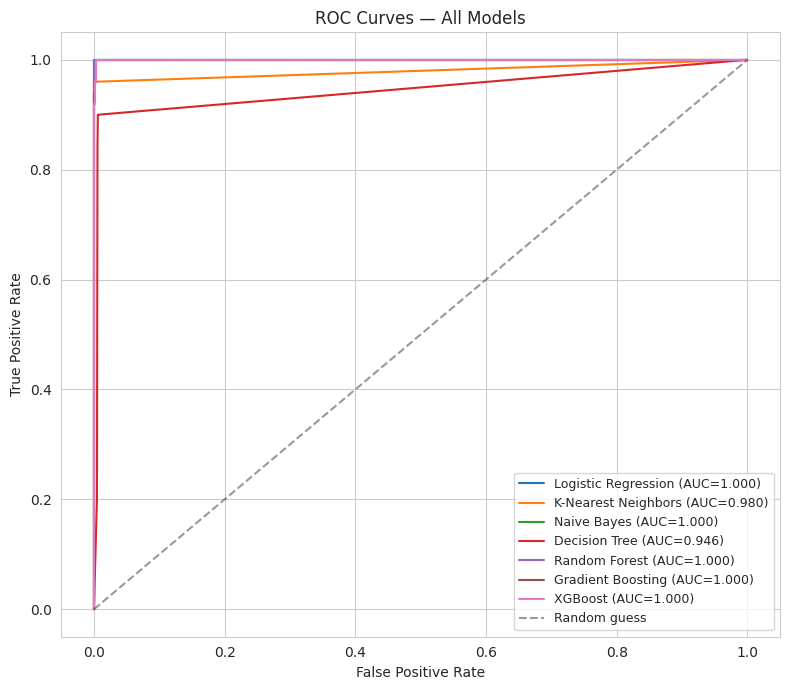

In [17]:
plt.figure(figsize=(8, 7))
for name, (fpr, tpr, auc_val) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.3f})")
plt.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random guess')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Models")
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()


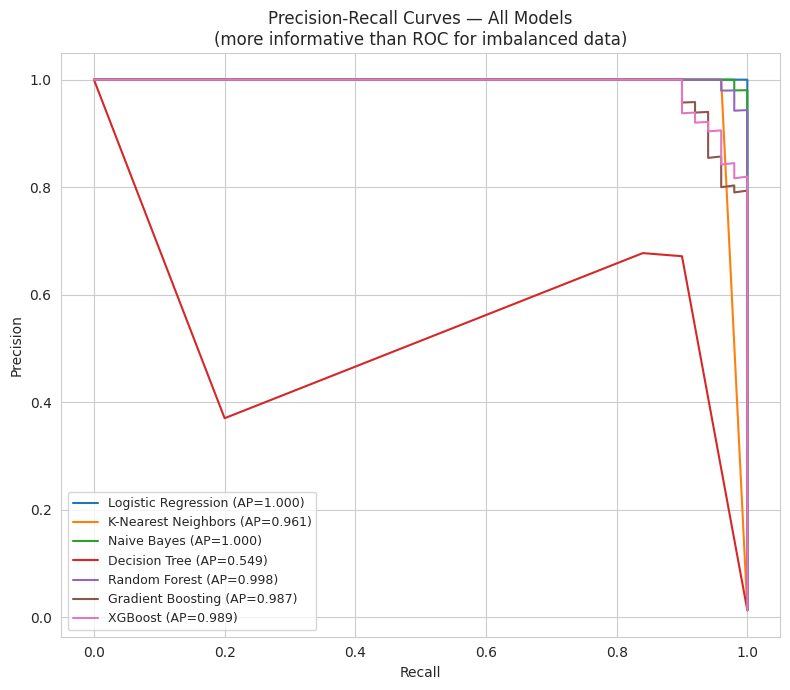

In [18]:
plt.figure(figsize=(8, 7))
for name, (prec_curve, rec_curve, ap) in pr_data.items():
    plt.plot(rec_curve, prec_curve, label=f"{name} (AP={ap:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves — All Models\n(more informative than ROC for imbalanced data)")
plt.legend(loc='lower left', fontsize=9)
plt.tight_layout()
plt.show()


Best model by F1-Score: Logistic Regression


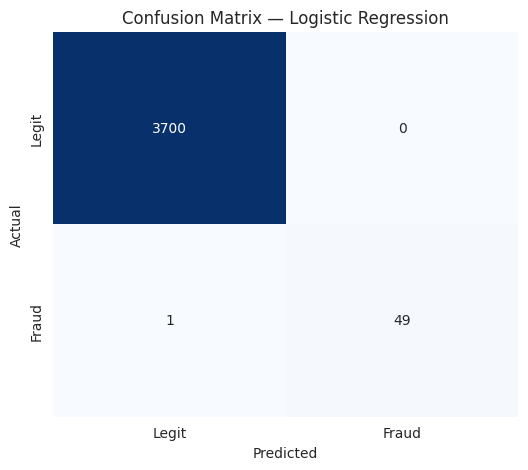


Classification Report:

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00      3700
       Fraud       1.00      0.98      0.99        50

    accuracy                           1.00      3750
   macro avg       1.00      0.99      0.99      3750
weighted avg       1.00      1.00      1.00      3750



In [19]:
best_model_name = results_df.iloc[0]["Model"]
best_model = fitted_models[best_model_name]
print(f"Best model by F1-Score: {best_model_name}")

y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
plt.title(f'Confusion Matrix — {best_model_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_best, target_names=['Legitimate', 'Fraud']))


## 7. Feature Importance (Tree-Based Models)

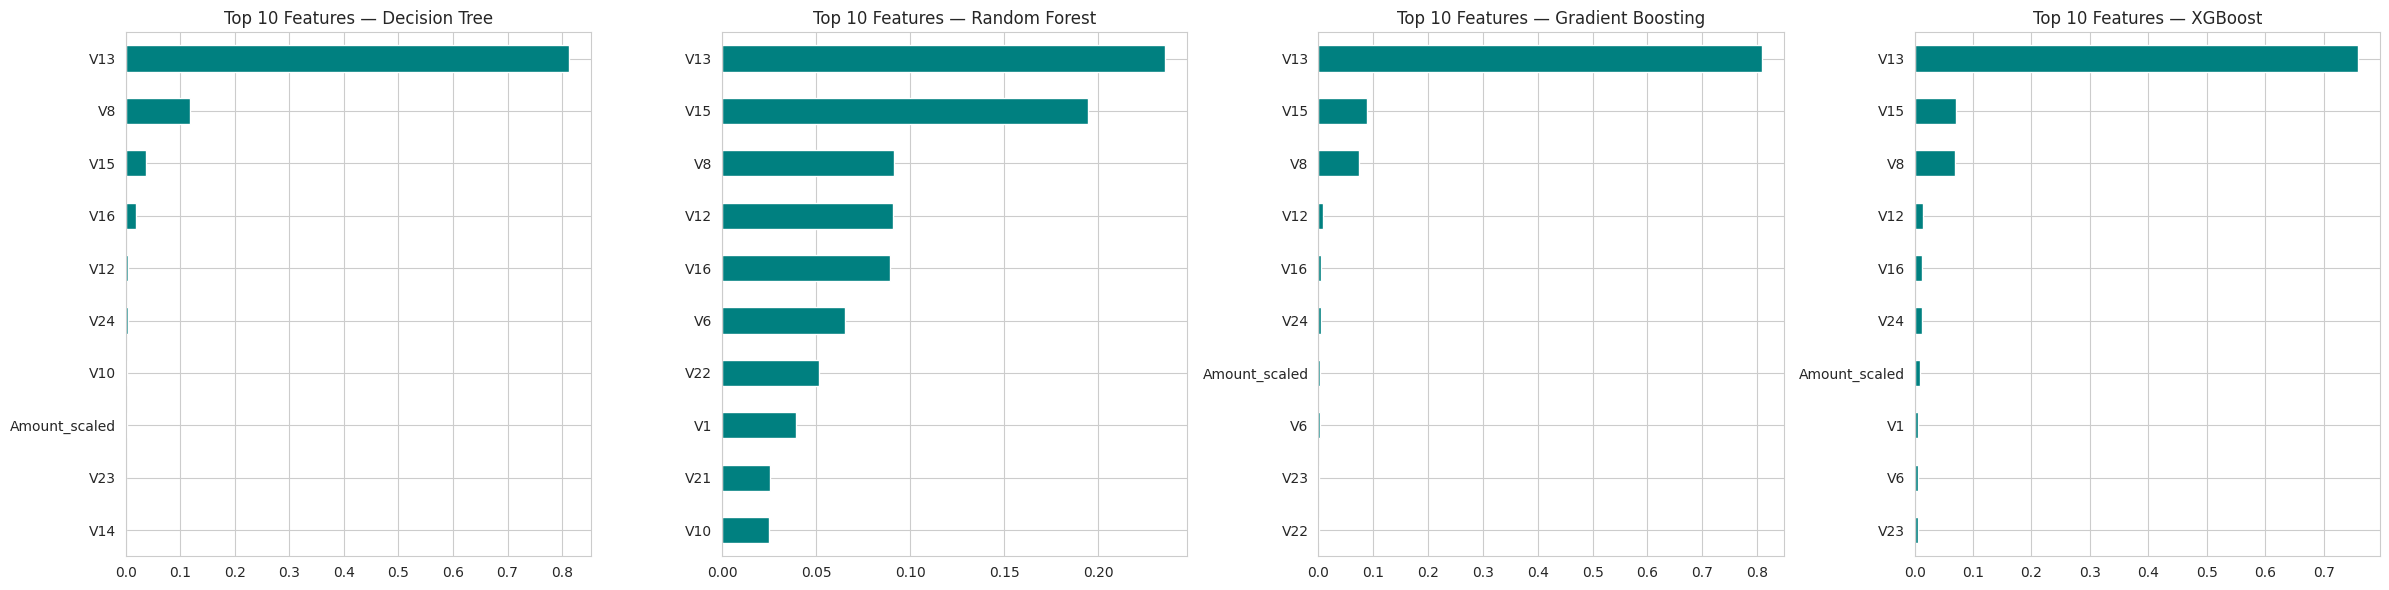

In [20]:
tree_models = {k: v for k, v in fitted_models.items() if hasattr(v, "feature_importances_")}

if tree_models:
    fig, axes = plt.subplots(1, len(tree_models), figsize=(6 * len(tree_models), 6))
    if len(tree_models) == 1:
        axes = [axes]
    for ax, (name, model) in zip(axes, tree_models.items()):
        importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
        importances.sort_values().plot(kind='barh', ax=ax, color='teal')
        ax.set_title(f"Top 10 Features — {name}")
    plt.tight_layout()
    plt.show()
else:
    print("No tree-based models with feature_importances_ available.")


## 8. Cross-Validation Sanity Check

A quick 5-fold stratified cross-validation on the best model confirms the result is stable and not a lucky train/test split.


In [21]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(best_model, X, y, cv=cv, scoring='f1', n_jobs=-1)
print(f"{best_model_name} — 5-fold CV F1 scores: {np.round(cv_scores, 4)}")
print(f"Mean F1: {cv_scores.mean():.4f}  (+/- {cv_scores.std():.4f})")


Logistic Regression — 5-fold CV F1 scores: [1. 1. 1. 1. 1.]
Mean F1: 1.0000  (+/- 0.0000)


## 9. Save the Best Model

Persist the winning model and the scaler so the pipeline can be reused for inference without retraining.


In [22]:
joblib.dump(best_model, f"best_model_{best_model_name.replace(' ', '_').lower()}.pkl")
joblib.dump(scaler, "amount_time_scaler.pkl")
print(f"Saved: best_model_{best_model_name.replace(' ', '_').lower()}.pkl")
print("Saved: amount_time_scaler.pkl")


Saved: best_model_logistic_regression.pkl
Saved: amount_time_scaler.pkl


## 10. Conclusion & Next Steps

**Summary:** We trained and evaluated up to 7 algorithms on a highly imbalanced fraud dataset, using SMOTE to rebalance the training data and PR-AUC / F1 / Recall as the primary metrics (accuracy is misleading on imbalanced data — a model predicting "legitimate" every time would still score ~98.7% accuracy).

**Key takeaways:**
- Ensemble methods (Random Forest, Gradient Boosting, XGBoost) generally outperform simpler linear models on this type of tabular, non-linearly-separable fraud data.
- **Recall** matters most in fraud detection — missing a fraudulent transaction (false negative) is typically far costlier than flagging a legitimate one for review (false positive).
- PR-AUC is a more honest metric than ROC-AUC when the positive class is rare.

**Possible extensions:**
- Try deep learning (autoencoders for anomaly detection, or a simple feed-forward network).
- Hyperparameter tuning via `GridSearchCV` / `Optuna`.
- Cost-sensitive learning with a custom business cost matrix (false negative cost >> false positive cost).
- Deploy the saved model behind a REST API (FastAPI/Flask) for real-time scoring.
- Use SHAP values for explainability on individual fraud predictions.
